In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
def compute_diversity_score(topic_model):
    """
    Compute topic diversity score as the ratio of unique keywords 
    to total keywords across all topics (excluding topic -1).
    """
    topics_ = topic_model.get_topics()
    all_words = [
        word for topic_id, words in topics_.items() if topic_id != -1
        for word, _ in words
    ]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if all_words else 0

In [3]:
import re
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def compute_coherence_score(
    topic_model,
    docs, 
    top_n_words = 5,
    coherence = 'c_v'
):
    """
    Compute topic cohernece score using gensim 
    across all topics (excluding topic -1).
    """

    # Tokenize documents with a clean, custom tokenizer
    def clean_tokenizer(doc):
        return re.findall(r'\b[a-zA-Z][a-zA-Z0-9\-]{2,}\b', doc.lower())

    tokenized_docs = [clean_tokenizer(doc) for doc in docs if isinstance(doc, str) and doc.strip()]

    # Build gensim Dictionary
    dictionary = Dictionary(tokenized_docs)

    # Restrict to vectorizer's vocabulary
    vectorizer = topic_model.vectorizer_model
    vocab = set(vectorizer.get_feature_names_out())

    # Extract top words from each topic, filtering out -1
    topic_words = []
    for topic_id in topic_model.get_topic_info().Topic.tolist():
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        filtered = [w for w in words if w in vocab and w in dictionary.token2id]
        if filtered:
            topic_words.append(filtered)

    # Compute coherence
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence=coherence
    )

    return coherence_model.get_coherence()

In [4]:
from collections import Counter

def topic_model_analysis(topic_model, docs):
    """
    Analyze the BERTopic model:
    - Reports number of outliers (topic -1)
    - Computes topic diversity score
    - Computes topic cohernece score
    - Prints topic summary table
    """
    # Get topic assignment info for each document
    df_info = topic_model.get_document_info(docs)
    
    # Outlier analysis
    total_docs = len(df_info)
    num_outliers = (df_info['Topic'] == -1).sum()
    outlier_ratio = num_outliers / total_docs

    print(f"Total documents: {total_docs}\n")
    print(f"Documents assigned to topic -1: {num_outliers} ({outlier_ratio:.2%})\n")

    # Topic diversity score
    diversity_score = compute_diversity_score(topic_model)
    print(f"Topic Diversity Score: {diversity_score:.4f}\n")

    coherence_score = compute_coherence_score(topic_model, docs)
    print(f"Topic Coherence Score: {coherence_score:.4f}\n")

    # Topic summary
    print("Topic Summary:")
    print(topic_model.get_topic_info())

In [5]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [6]:
embeddings = np.load('../Model/emb_all-MiniLM-L6-v2.npy')

description_text = pd.read_csv('../Output/london_app_doc.csv')
docs = description_text['description'].tolist()

stop_words_ = ['of', 'and', 'to', 'with', 'the', 'at', 'into', 'from', 'in', 'for', 'as', 'on'] + ["an"]

vectorizer_model = CountVectorizer(
    stop_words=stop_words_,
    ngram_range=(1,2)  
)

topic_model_rt = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_reduced_90.pkl")

features_reduced = pd.read_csv('../Output/NLP Output/feature_extraction_reduced_90.csv')

topics_reduced = features_reduced['topic'].to_list()

import ast
probs_reduced = [ast.literal_eval(p) for p in features_reduced['probabilities']]

In [ ]:
import copy

def strategy_threshold_analysis(model, docs, topics, thresholds, strategy="c-tf-idf", coherence='c_v', top_n_words=5, plot=True):
    """
    Analyze outlier ratio, coherence, and diversity under different thresholds.
    """

    print(f"Using strategy {strategy}...")

    outlier_ratios = []
    coherence_scores = []
    diversity_scores = []

    for t in thresholds:
        # Deepcopy model to avoid state pollution across thresholds
        model_ = copy.deepcopy(model)

        # Apply outlier reduction
        if strategy == 'probabilities':
            new_topics = model_.reduce_outliers(docs, topics, probabilities=probs_reduced, strategy=strategy, threshold=t)
        else :
            new_topics = model_.reduce_outliers(docs, topics, strategy=strategy, threshold=t)
            
        outlier_ratio = (np.array(new_topics) == -1).sum() / len(new_topics)

        # Update model with new topics
        model_.update_topics(docs, topics=new_topics)

        # Recompute coherence and diversity on clean model
        coherence_score = compute_coherence_score(model_, docs, top_n_words=top_n_words, coherence=coherence)
        diversity_score = compute_diversity_score(model_)

        print(f"Threshold: {t:.2f} → Outlier: {outlier_ratio:.2%}, Coherence: {coherence_score:.4f}, Diversity: {diversity_score:.4f}")

        outlier_ratios.append(outlier_ratio)
        coherence_scores.append(coherence_score)
        diversity_scores.append(diversity_score)
    
    if strategy == "c-tf-idf" and plot:
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].plot(thresholds, outlier_ratios, marker='o', color='tab:red', label="Outlier Ratio")
        axes[0].set_title("Outlier Ratio vs. Threshold", fontsize=14, fontweight='bold')
        axes[0].set_xlabel("Threshold", fontsize=12, fontweight='bold')
        axes[0].set_ylabel("Outlier Ratio", fontsize=12, fontweight='bold')
        axes[0].grid(True)
        axes[0].legend()

        axes[1].plot(thresholds, coherence_scores, marker='s', label='Coherence', color='tab:blue')
        axes[1].plot(thresholds, diversity_scores, marker='^', label='Diversity', color='tab:green')
        axes[1].set_title("Coherence & Diversity vs. Threshold", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Threshold", fontsize=12, fontweight='bold')
        axes[1].set_ylabel("Score", fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True)

        plt.suptitle(f"Threshold Analysis - Strategy: {strategy}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

Using strategy c-tf-idf...


2025-07-22 12:37:18,035 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.05 → Outlier: 0.72%, Coherence: 0.7342, Diversity: 0.3820


2025-07-22 12:37:48,081 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.10 → Outlier: 7.49%, Coherence: 0.7348, Diversity: 0.3719


...

Threshold: 0.70 → Outlier: 42.77%, Coherence: 0.7119, Diversity: 0.4303


2025-07-22 12:41:45,494 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.80 → Outlier: 42.78%, Coherence: 0.7120, Diversity: 0.4303


2025-07-22 12:42:14,894 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.90 → Outlier: 42.79%, Coherence: 0.7115, Diversity: 0.4303


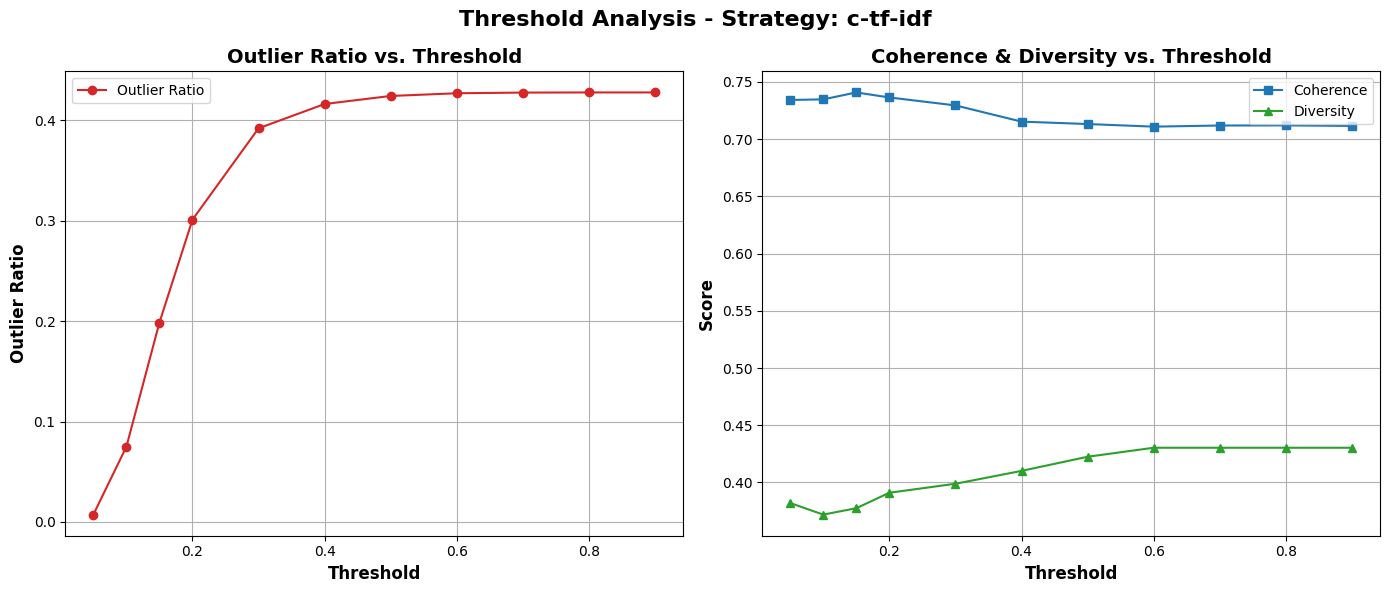

In [9]:
strategy_threshold_analysis(topic_model_rt, docs, topics_reduced, thresholds=[0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], strategy="c-tf-idf")

In [10]:
strategy_threshold_analysis(topic_model_rt, docs, topics_reduced, thresholds=[0], strategy="embeddings", plot=False)
strategy_threshold_analysis(topic_model_rt, docs, topics_reduced, thresholds=[0], strategy="distributions", plot=False)
strategy_threshold_analysis(topic_model_rt, docs, topics_reduced, thresholds=[0], strategy="probabilities", plot=False)

Using strategy embeddings...


2025-07-22 12:52:00,500 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.00 → Outlier: 0.00%, Coherence: 0.7456, Diversity: 0.3933
Using strategy distributions...


2025-07-22 12:52:43,198 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.00 → Outlier: 0.00%, Coherence: 0.7271, Diversity: 0.4011
Using strategy probabilities...


2025-07-22 12:53:12,230 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Threshold: 0.00 → Outlier: 0.00%, Coherence: 0.7168, Diversity: 0.4191
